# Nonhomogeneous Warping

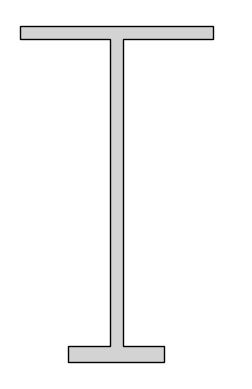

In [1]:
import veux
from xsection.analysis import WarpingAnalysis
from xsection.library import DoubleFlange, Rectangle
from xsection import CompositeSection
from xara import Section, Material 
G = 76.92
E = 200.0

materials = {
    "1": Material(E=E, G=G),
    "2": Material(E=E/10, G=G/10)
}

h = 50
t = 0.04*h
bot = DoubleFlange(d=h, 
                   b2=0.3*h, 
                   b1=0.6*h, 
                   t2=1.25*t, 
                   t1=t,
                   tw=t, 
                   material=materials["1"],
                #    group="1", 
                   mesh_scale=1/30
)
veux.draw_shape(bot)

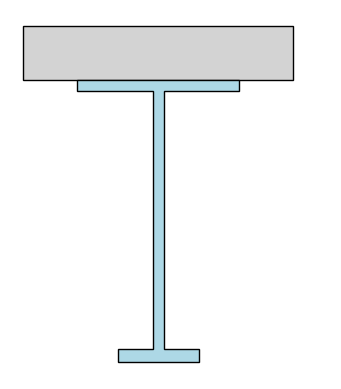

In [2]:
d = 0.2*h
top = Rectangle(d=d, b=h,# group="2", 
                mesh_scale=1/40, 
                material=materials["2"])
top = top.translate([0, d/2+t/2])

shape = CompositeSection([top, bot])
veux.draw_shape(shape)

In [3]:
sv = WarpingAnalysis(shape)
GJ = sv.twist_rigidity()
GJ/materials["1"]["G"]


3978.7080799021683

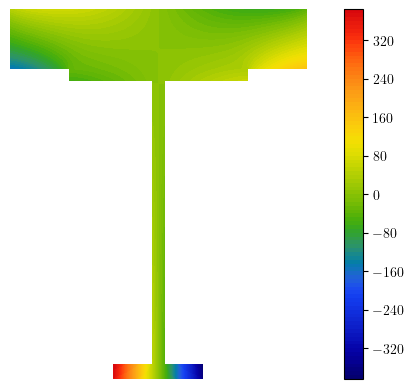

In [5]:
artist = veux.ShapeArtist(shape)
artist.draw_surfaces(field=sv.solve_twist())